In [ ]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!\n")

Libraries imported successfully!



In [ ]:
np.random.seed(42)  # For reproducibility

n_samples = 200

# Generate features
study_hours = np.random.uniform(0, 10, n_samples)
attendance = np.random.uniform(40, 100, n_samples)
previous_score = np.random.uniform(30, 95, n_samples)

# Generate binary outcome (pass=1, fail=0) with some logic
# Higher study hours, attendance, and previous score increase probability of passing
z = -8 + 0.5*study_hours + 0.05*attendance + 0.08*previous_score + np.random.normal(0, 2, n_samples)
probability = 1 / (1 + np.exp(-z))
pass_fail = (probability > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'previous_score': previous_score,
    'pass': pass_fail
})

print("Sample Data (first 10 rows):")
print(data.head(10))
print(f"\nDataset shape: {data.shape}")
print(f"\nPass rate: {data['pass'].mean():.2%}\n")

Sample Data (first 10 rows):
   study_hours  attendance  previous_score  pass
0     3.745401   78.521899       36.703051     0
1     9.507143   45.048398       88.665939     1
2     7.319939   49.697723       62.841404     1
3     5.986585   93.913251       83.719735     1
4     1.560186   76.385744       50.803224     0
5     1.559945   40.551823       88.209010     0
6     0.580836   46.088293       55.298109     1
7     8.661761   79.810106       30.704447     1
8     6.011150   40.303695       88.849828     1
9     7.080726   49.648483       35.933634     1

Dataset shape: (200, 4)

Pass rate: 81.50%



In [ ]:
# Define features (X) and target (y)
X = data[['study_hours', 'attendance', 'previous_score']]
y = data['pass']

# Add constant (intercept) to the model
X = sm.add_constant(X)

print("Features prepared with intercept added.\n")

Features prepared with intercept added.



In [ ]:
# Create GLM model with Binomial family (for binary outcomes)
model = sm.GLM(y, X, family=sm.families.Binomial())

# Fit the model
result = model.fit()

# Display full summary
print("="*70)
print("MODEL SUMMARY")
print("="*70)
print(result.summary())
print("\n")

MODEL SUMMARY
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   pass   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -59.260
Date:                Mon, 17 Nov 2025   Deviance:                       118.52
Time:                        15:34:00   Pearson chi2:                     147.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3059
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -8.6968     

In [ ]:
print("="*70)
print("COEFFICIENTS INTERPRETATION")
print("="*70)

coefficients = result.params
print("\nCoefficients:")
print(coefficients)
print("\n")

for feature, coef in coefficients.items():
    if feature == 'const':
        print(f"• Intercept: {coef:.4f}")
    else:
        direction = "increases" if coef > 0 else "decreases"
        print(f"• {feature}: {coef:.4f}")
        print(f"  → A 1-unit increase in {feature} {direction} the log-odds of passing")

print("\n")

COEFFICIENTS INTERPRETATION

Coefficients:
const            -8.696827
study_hours       0.582974
attendance        0.049526
previous_score    0.079770
dtype: float64


• Intercept: -8.6968
• study_hours: 0.5830
  → A 1-unit increase in study_hours increases the log-odds of passing
• attendance: 0.0495
  → A 1-unit increase in attendance increases the log-odds of passing
• previous_score: 0.0798
  → A 1-unit increase in previous_score increases the log-odds of passing




In [ ]:
print("="*70)
print("ODDS RATIOS INTERPRETATION")
print("="*70)

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

print("\nOdds Ratios:")
print(odds_ratios)
print("\n")

for feature, odds_ratio in odds_ratios.items():
    if feature == 'const':
        continue
    else:
        if odds_ratio > 1:
            percent_change = (odds_ratio - 1) * 100
            print(f"• {feature}: {odds_ratio:.4f}")
            print(f"  → For every 1-unit increase in {feature}, the odds of passing")
            print(f"     increase by {percent_change:.2f}% (multiply by {odds_ratio:.4f})")
        else:
            percent_change = (1 - odds_ratio) * 100
            print(f"• {feature}: {odds_ratio:.4f}")
            print(f"  → For every 1-unit increase in {feature}, the odds of passing")
            print(f"     decrease by {percent_change:.2f}% (multiply by {odds_ratio:.4f})")
        print()


ODDS RATIOS INTERPRETATION

Odds Ratios:
const             0.000167
study_hours       1.791359
attendance        1.050773
previous_score    1.083038
dtype: float64


• study_hours: 1.7914
  → For every 1-unit increase in study_hours, the odds of passing
     increase by 79.14% (multiply by 1.7914)

• attendance: 1.0508
  → For every 1-unit increase in attendance, the odds of passing
     increase by 5.08% (multiply by 1.0508)

• previous_score: 1.0830
  → For every 1-unit increase in previous_score, the odds of passing
     increase by 8.30% (multiply by 1.0830)



In [ ]:
print("="*70)
print("95% CONFIDENCE INTERVALS FOR ODDS RATIOS")
print("="*70)

# Get confidence intervals for coefficients
conf_int = result.conf_int()
conf_int.columns = ['Lower CI', 'Upper CI']

# Convert to odds ratios
odds_ratios_ci = np.exp(conf_int)
odds_ratios_ci['Odds Ratio'] = odds_ratios

print("\n", odds_ratios_ci)
print("\n")


95% CONFIDENCE INTERVALS FOR ODDS RATIOS

                 Lower CI  Upper CI  Odds Ratio
const           0.000005  0.005243    0.000167
study_hours     1.436157  2.234411    1.791359
attendance      1.021329  1.081065    1.050773
previous_score  1.049885  1.117238    1.083038




In [ ]:
print("="*70)
print("SAMPLE PREDICTIONS")
print("="*70)

# Make predictions on the training data
predictions = result.predict(X)

# Show some examples
sample_predictions = pd.DataFrame({
    'study_hours': data['study_hours'][:5],
    'attendance': data['attendance'][:5],
    'previous_score': data['previous_score'][:5],
    'actual_pass': data['pass'][:5],
    'predicted_probability': predictions[:5],
    'predicted_pass': (predictions[:5] > 0.5).astype(int)
})

print("\n", sample_predictions)
print("\n")

SAMPLE PREDICTIONS

    study_hours  attendance  previous_score  actual_pass  \
0     3.745401   78.521899       36.703051            0   
1     9.507143   45.048398       88.665939            1   
2     7.319939   49.697723       62.841404            1   
3     5.986585   93.913251       83.719735            1   
4     1.560186   76.385744       50.803224            0   

   predicted_probability  predicted_pass  
0               0.575251               1  
1               0.997870               1  
2               0.954553               1  
3               0.997812               1  
4               0.512089               1  




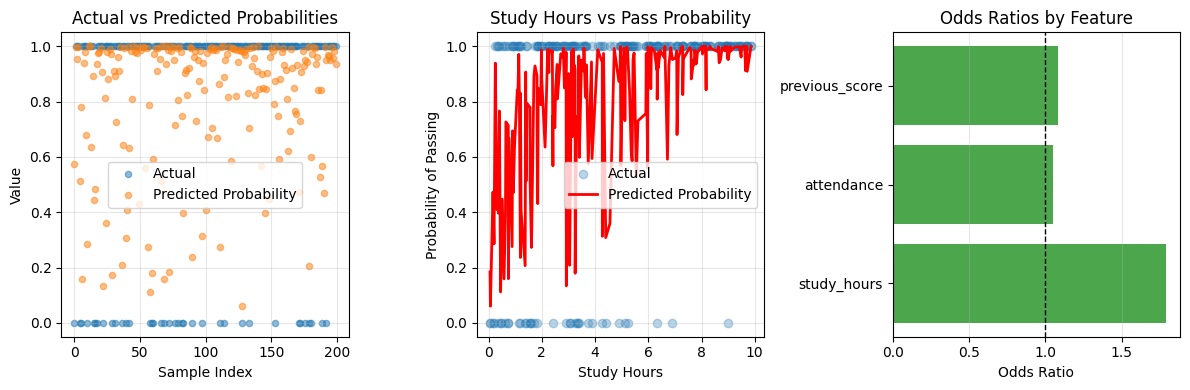

In [ ]:
# Plot 1: Actual vs Predicted Probabilities
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(range(len(y)), y, alpha=0.5, label='Actual', s=20)
plt.scatter(range(len(predictions)), predictions, alpha=0.5, label='Predicted Probability', s=20)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Study Hours vs Pass Probability
plt.subplot(1, 3, 2)
sorted_idx = np.argsort(data['study_hours'])
plt.scatter(data['study_hours'], y, alpha=0.3, label='Actual')
plt.plot(data['study_hours'].iloc[sorted_idx], predictions.iloc[sorted_idx],
         color='red', linewidth=2, label='Predicted Probability')
plt.xlabel('Study Hours')
plt.ylabel('Probability of Passing')
plt.title('Study Hours vs Pass Probability')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Odds Ratios Bar Chart
plt.subplot(1, 3, 3)
odds_ratios_plot = odds_ratios.drop('const')
colors = ['green' if x > 1 else 'red' for x in odds_ratios_plot]
plt.barh(odds_ratios_plot.index, odds_ratios_plot.values, color=colors, alpha=0.7)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Odds Ratios by Feature')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
print("="*70)
print("KEY TAKEAWAYS")
print("="*70)
print("""
1. GLM Framework: Generalized Linear Models extend linear regression to
   handle different types of outcomes (binary, count, etc.)

2. Logistic Regression: A type of GLM for binary outcomes (0/1)
   - Uses the logistic (sigmoid) function to predict probabilities

3. Coefficients: Tell us the direction and strength of relationships
   - Positive coefficient = feature increases likelihood of outcome
   - Negative coefficient = feature decreases likelihood of outcome

4. Odds Ratios: Easier to interpret than raw coefficients
   - Calculated as: exp(coefficient)
   - Odds Ratio > 1: Feature increases odds of outcome
   - Odds Ratio < 1: Feature decreases odds of outcome
   - Odds Ratio = 1: Feature has no effect

5. Interpretation Example:
   If study_hours has odds ratio of 1.65:
   "Each additional study hour multiplies the odds of passing by 1.65"
   (or "increases odds by 65%")
""")

KEY TAKEAWAYS

1. GLM Framework: Generalized Linear Models extend linear regression to 
   handle different types of outcomes (binary, count, etc.)

2. Logistic Regression: A type of GLM for binary outcomes (0/1)
   - Uses the logistic (sigmoid) function to predict probabilities

3. Coefficients: Tell us the direction and strength of relationships
   - Positive coefficient = feature increases likelihood of outcome
   - Negative coefficient = feature decreases likelihood of outcome

4. Odds Ratios: Easier to interpret than raw coefficients
   - Calculated as: exp(coefficient)
   - Odds Ratio > 1: Feature increases odds of outcome
   - Odds Ratio < 1: Feature decreases odds of outcome
   - Odds Ratio = 1: Feature has no effect

5. Interpretation Example:
   If study_hours has odds ratio of 1.65:
   "Each additional study hour multiplies the odds of passing by 1.65"
   (or "increases odds by 65%")

